# CO5420 Air Pollution Forecasting

## 02 — Traditional Baselines

## tl;dr

Four reference models were evaluated on identical chronological
target splits. Gradient boosting achieved the best traditional
validation RMSE (`16.7294`), while Ridge achieved the best
traditional local-test RMSE (`26.0475`). Both learned baselines
beat persistence on validation. The large validation-to-local-test
shift shows why a held-out future period is essential.

## Context & Methods

The baselines establish how much value is added by learning and by
neural architectures.

Models:

1. **Persistence:** predict the last observed PM2.5 value.
2. **Historical mean:** predict the 24-hour PM2.5 mean.
3. **Ridge regression:** regularised linear model.
4. **Histogram gradient boosting:** nonlinear tree ensemble.

Ridge and gradient boosting use 115 engineered tabular features:
the latest 43 processed inputs, all 24 PM2.5 lags, 24-hour
numerical summaries, and PM2.5 changes over 1, 3, 6, and 12 hours.

### Key Assumptions

- Split membership is based on the target timestamp.
- Model selection uses validation RMSE.
- The local-test period is a final generalisation check.
- No Kaggle or hidden test labels are used.

## Data

In [1]:
from __future__ import annotations

from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Metrics directory exists: {METRICS_DIR.exists()}")

Project root: /mnt/c/Users/wijer/Documents/GitHub/co-5420-air-pollution
Metrics directory exists: True


In [2]:
baseline_metrics = pd.read_csv(
    METRICS_DIR / "baseline_metrics.csv"
)
station_metrics = pd.read_csv(
    METRICS_DIR / "baseline_station_metrics.csv"
)
range_metrics = pd.read_csv(
    METRICS_DIR / "baseline_pollution_range_metrics.csv"
)
feature_metadata = json.loads(
    (METRICS_DIR / "baseline_feature_names.json").read_text()
)

assert set(baseline_metrics["model"]) == {
    "persistence",
    "historical_mean",
    "ridge",
    "gradient_boosting",
}
assert set(baseline_metrics["split"]) == {
    "validation",
    "local_test",
}
assert feature_metadata["feature_count"] == 115

print(f"Models: {baseline_metrics['model'].nunique()}")
print(f"Engineered features: {feature_metadata['feature_count']}")
display(baseline_metrics.sort_values(["split", "rmse"]))

Models: 4
Engineered features: 115


,model,split,samples,training_seconds,rmse,mae,r2
0,ridge,local_test,25891,3.4194,26.0475,12.4372,0.9481
1,persistence,local_test,25891,0.0000,27.4611,12.3133,0.9423
2,gradient_boosting,local_test,25891,10.3318,31.1928,12.6062,0.9255
3,historical_mean,local_test,25891,0.0000,79.2034,45.6075,0.5197
4,gradient_boosting,validation,25458,10.3318,16.7294,8.5922,0.9635
5,ridge,validation,25458,3.4194,16.7889,9.3273,0.9632
6,persistence,validation,25458,0.0000,17.6065,9.0208,0.9595
7,historical_mean,validation,25458,0.0000,50.7812,30.5809,0.6632


## Results

In [3]:
comparison = baseline_metrics.pivot(
    index="model",
    columns="split",
    values=["rmse", "mae", "r2"],
)
comparison = comparison.sort_values(
    ("rmse", "validation")
)
display(comparison)

rmse                   mae                    r2  \
split             local_test validation local_test validation local_test   
model                                                                      
gradient_boosting    31.1928    16.7294    12.6062     8.5922     0.9255   
ridge                26.0475    16.7889    12.4372     9.3273     0.9481   
persistence          27.4611    17.6065    12.3133     9.0208     0.9423   
historical_mean      79.2034    50.7812    45.6075    30.5809     0.5197   

                              
split             validation  
model                         
gradient_boosting     0.9635  
ridge                 0.9632  
persistence           0.9595  
historical_mean       0.6632

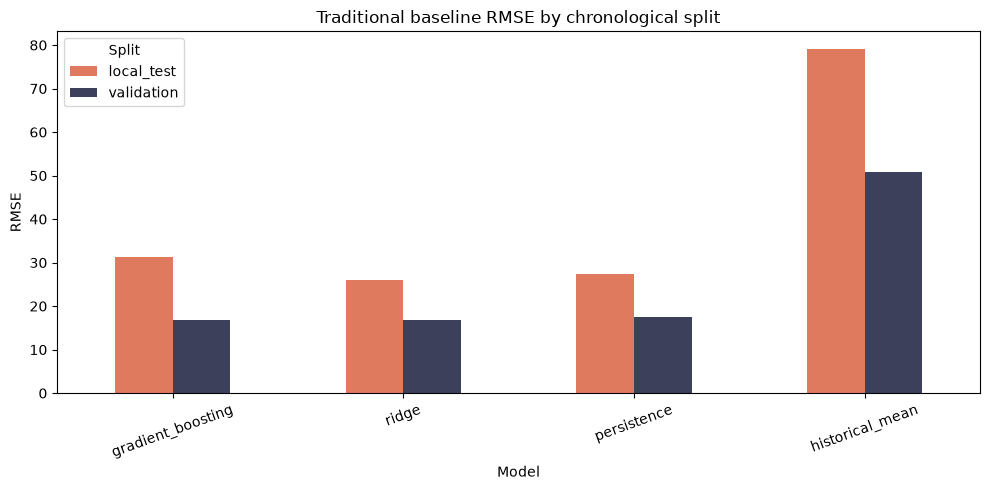

In [4]:
rmse_table = baseline_metrics.pivot(
    index="model",
    columns="split",
    values="rmse",
).sort_values("validation")

axis = rmse_table.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#E07A5F", "#3D405B"],
)
axis.set_title("Traditional baseline RMSE by chronological split")
axis.set_xlabel("Model")
axis.set_ylabel("RMSE")
axis.tick_params(axis="x", rotation=20)
axis.legend(title="Split")
plt.tight_layout()
plt.show()

### Station and pollution-range checks

In [5]:
ridge_local_stations = (
    station_metrics.loc[
        (station_metrics["model"] == "ridge")
        & (station_metrics["split"] == "local_test")
    ]
    .sort_values("rmse")
    [["station", "samples", "rmse", "mae", "r2"]]
)

ridge_ranges = (
    range_metrics.loc[
        (range_metrics["model"] == "ridge")
        & (range_metrics["split"] == "local_test")
    ]
    .sort_values("pollution_range")
    [["pollution_range", "samples", "rmse", "mae", "r2"]]
)

print("Ridge local-test station performance")
display(ridge_local_stations)
print("Ridge local-test performance by PM2.5 range")
display(ridge_ranges)

Ridge local-test station performance


,station,samples,rmse,mae,r2
76,Guanyuan,2172,24.0044,11.9342,0.9571
78,Huairou,2136,24.1587,11.4582,0.9381
79,Nongzhanguan,2170,24.2558,12.8020,0.9589
81,Tiantan,2167,25.0474,12.7284,0.9548
82,Wanliu,2167,25.0818,11.6965,0.9514
72,Aotizhongxin,2161,25.2192,12.1142,0.9541
77,Gucheng,2164,25.3208,13.1785,0.9551
75,Dongsi,2173,26.4111,13.0888,0.9542
73,Changping,2158,27.2275,11.8752,0.9061
80,Shunyi,2157,27.6132,13.5632,0.9473


Ridge local-test performance by PM2.5 range


,pollution_range,samples,rmse,mae,r2
30,0-35,12772,12.0790,6.2831,-1.3565
33,150-250,2868,29.5302,19.0070,-0.0330
34,250+,2247,64.0655,37.5409,0.7036
31,35-75,3773,19.9945,11.2739,-2.0259
32,75-150,4246,24.1825,14.2927,-0.2928


## Takeaways

- Learning from lagged context improves substantially over the
  historical-mean baseline.
- Gradient boosting narrowly wins validation among traditional
  models, but Ridge generalises better to the later local-test
  period.
- Errors increase during severe-pollution events, so overall RMSE
  must be accompanied by pollution-range analysis.
- The 115-feature representation is retained for the feedforward
  neural-network comparison.

Reproduce these results from the repository root:

```bash
conda activate co5420-air-gpu
python -m scripts.run_baselines
```